```Good morning, gent!
The year is 1945. The British forces are about to wipe out the Nazis, once and for all.
You are a young enthusiast meteorologist, and you are about to give the Great British Empire its victory!
At your disposal is the Royal Dataset of Measurements from forecasting stations around the globe. Measurements are taken each morning and each noon. Since we are British, we don't believe in surprise attacks. Leave that rubbish for the barbarians. Instead, we spend each morning preparing for the battle, and attack the bloody Nazis by noon, like gentlemen. Hence, it is of utter importance that you can forecast the temperatures at noon each day.
Are you ready for the mission? Are you ready to destroy the Nazis?```

```~Ittai Haran```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import plotly.express as pex
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import keras
from keras.layers import Dense
import keras.ops as O

%matplotlib inline

```Start by reading the Royal Dataset of Measurements. Also at your disposal is the data_weather_station_locations dataset. As a former meteorologist myself, I suggest you merge it into your measurements dataset.
Split your data properly (remember that the British army wants to keep its time travel abilities in secret for a little longer). Split it such that you have 70% of the data in your training segment.
Do you have missing values in your dataset? or any categorical values? deal with them with care.```

In [3]:
df = pd.read_csv("data/Royal_Dataset_of_Measurements.csv")
# df = df[df["MiddayTemp"] < 1e10]
def get_x_y_from_df(df):
    x = df.drop(columns=["Date", "MiddayTemp", "PRCP", "SNF"])
    y = df["MiddayTemp"]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)


    def fill_na_mean(x_train, x_test, col):
        col_mean = x_train[col].mean()
        x_train[col] = x_train[col].fillna(col_mean)
        x_test[col] = x_test[col].fillna(col_mean)
        return x_train, x_test

    x_train, x_test = fill_na_mean(x_train, x_test, "Precip")
    x_train, x_test = fill_na_mean(x_train, x_test, "Snowfall")

    sta_locs = pd.read_csv("data/data_weather_station_locations.csv")[["STA", "Longitude", "Latitude"]]

    sta_long = sta_locs.set_index("STA")["Longitude"]
    sta_lat = sta_locs.set_index("STA")["Latitude"]

    x_train["Longitude"] = x_train["STA"].map(sta_long)
    x_train["Latitude"] = x_train["STA"].map(sta_lat)

    long_mean = x_train["Longitude"].mean()
    lat_mean = x_train["Latitude"].mean()

    x_train["Longitude"] = x_train["Longitude"].fillna(long_mean)
    x_train["Latitude"] = x_train["Latitude"].fillna(lat_mean)

    x_test["Longitude"] = x_test["STA"].map(sta_long).fillna(long_mean)
    x_test["Latitude"] = x_test["STA"].map(sta_lat).fillna(lat_mean)

    # for later
    station_weights = x_train["STA"].map(1/x_train.groupby("STA")["STA"].count())

    x_train = x_train.drop(columns=["STA"])
    x_test = x_test.drop(columns=["STA"])
    return x_train, x_test, y_train, y_test, station_weights

x_train, x_test, y_train, y_test, _ = get_x_y_from_df(df)
sta_locs = pd.read_csv("data/data_weather_station_locations.csv")[["STA", "Longitude", "Latitude"]]


```Just for warmup: where are the forecasting stations? Show them all on a single map, using your favorite tools. There are rumors about this sophisticated tool called "Google" that can help you do it.```

In [4]:
pex.scatter_geo(sta_locs, lat="Latitude", lon="Longitude", hover_name="STA").show(renderer="browser")

```I'm told that you need a definition for a loss function. well, I'm not such a technologist myself, but I can tell you that your loss should be linear in the absolute value of your error.
A friend from the Royal Navy once told me, "Aye stairt wi' a guid auld xgboost". I trust this friend, and you should too. What results did you get?```

In [5]:
def eval_xgb(x_train, x_test, y_train, y_test, metric=mean_squared_error, weights=None):
    model = xgb.XGBRegressor(n_estimators=500, max_depth=9, learning_rate=0.1)
    model.fit(x_train, y_train, sample_weight=weights)

    print(f"XGBoost Train metric: {metric(y_train, model.predict(x_train))}")

    print(f"XGBoost Test metric: {metric(y_test, model.predict(x_test))}")

eval_xgb(x_train, x_test, y_train, y_test)


XGBoost Train metric: 612692535499043.6
XGBoost Test metric: 2.979788513921457


```Heavens in the sky, that's not so good. This bloody scot, I never trusted him.
Let's try a different approach. Another friend, from the Royal Airforce, told me, "When you are preplexed and can't find your arms and legs, try training a neural net and look carefully at its loss".
I trust this friend very much. You should try what he suggested. Can you learn something to explains our poor results from earlier? Don't forget - neural networks work better when first normalizing your data.```

In [6]:
def eval_nn(x_train, x_test, y_train, y_test, bias=None, loss="mean_squared_error", metric="mean_squared_error", weights=None):
    inputs = keras.Input(shape=((len(x_train.columns)), ))

    x = Dense(512, activation="relu")(inputs)
    x = Dense(256, activation="relu")(x)
    x = Dense(128, activation="relu")(x)

    output = Dense(1, bias_initializer=bias)(x)

    model = keras.Model(inputs=inputs, outputs=output)

    model.summary()

    if type(metric) != list:
        metrics = [metric]
    else:
        metrics = metric


    model.compile(loss=loss, optimizer=keras.optimizers.Adam(learning_rate=1e-3), metrics=metrics)

    scaler = StandardScaler()
    x_train_normalized = scaler.fit_transform(x_train)
    x_test_normalized = scaler.transform(x_test)

    model.fit(x_train_normalized, y_train, batch_size=512, epochs=300, sample_weight=weights)

    train_metrics = model.evaluate(x_train_normalized, y_train, return_dict=True)
    test_metrics = model.evaluate(x_test_normalized, y_test, return_dict=True)

    print(f"NN Train metrics: {train_metrics}")
    print(f"NN Test metrics: {test_metrics}")

eval_nn(x_train, x_test, y_train, y_test, None, "mean_squared_error", "mean_squared_error")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,961 (660.00 KB)

 Trainable params: 168,961 (660.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1225385039626240.0000 - mean_squared_error: 1225385039626240.0000
Epoch 2/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1225385039626240.0000 - mean_squared_error: 1225385039626240.0000
Epoch 3/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1225385039626240.0000 - mean_squared_error: 1225385039626240.0000
Epoch 4/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1225385039626240.0000 - mean_squared_error: 1225385039626240.0000
Epoch 5/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1225385039626240.0000 - mean_squared_error: 1225385039626240.0000
Epoch 6/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1225385039626240.0000 - mean_squared_error: 1225385039626240.0000
Epoch 7/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1225385039626240.0000 - mean_squared_error: 1225385039626240.0000
Epoch 8/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1225384771190784.0000 - mean_squared_error: 122538

```As I suspected.. The wanker Nazis must have poisoned our dataset! Intel tells me that they could insert one sample at most. Find it and delete it from our Royal Dataset.```

In [7]:
df = pd.read_csv("data/Royal_Dataset_of_Measurements.csv")
df = df[df["MiddayTemp"] < 1e10]
x_train, x_test, y_train, y_test, station_weights = get_x_y_from_df(df)

```Blinding. Now train your xgboost and neural network again! What results can you get?
Let me drop another tip for you: when you have an idea of the mean of the target you try to predict, you can initiate the last layer's bias to be this mean. It can make your network converge so much faster!```

In [ ]:
mean_target = y_train.mean()
eval_nn(x_train, x_test, y_train, y_test, keras.initializers.Constant(mean_target), "mean_squared_error", "mean_squared_error")
eval_xgb(x_train, x_test, y_train, y_test)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,961 (660.00 KB)

 Trainable params: 168,961 (660.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 12.5946 - mean_squared_error: 12.5946
Epoch 2/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.0264 - mean_squared_error: 8.0264
Epoch 3/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9967 - mean_squared_error: 6.9967
Epoch 4/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.5518 - mean_squared_error: 6.5518
Epoch 5/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2096 - mean_squared_error: 6.2096
Epoch 6/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.8803 - mean_squared_error: 5.8803
Epoch 7/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.7087 - mean_squared_error: 5.7087
Epoch 8/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.3955 - mean_squared_error: 5.3955
Epoch 9/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.3249 - mean_squared_error: 5.3249
Epoch 10/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.1159 - mean_squared_error: 5.1159
Epoch 11/300
160/160 ━━━━━━

```I've got a new message from Bletchley. Apperantly, our troops are very sensitive to cold weather, but to warm weather? not so much. We should update our loss function accordingly. They gave me this formula, that I myself can't read, but you might:```

$\frac {\sum_i {|Pred_i-True_i|}}{\sum_i {Pred_i}}$

```Does it do what we want it to do? Are there any visible problems with this loss? List here all the problems that come to your mind, regarding this loss. Assuming you have only one sample in your dataset, draw the loss as a function of your prediction. Also, evaluate your former models using this metric.```


this means we want a loss that heavily penalizes predicting bigger values than the truth
and lightly penalizes predicting smaller ones.
The given one doesnt give any weight to whether $\text{Pred}_i > \text{True}_i$ but rather penalizes both smaller and bigger predictions exactly the same (due to the absolute value).
By dividing by the sum of the predictions we get smaller losses for bigger predictions, even if the distances between them and the targets are large. We also get negative loss for negative predictions and undefined behavior for 0 predictions, both of which are valid temperatures.


C:\Users\yovel\AppData\Local\Temp\ipykernel_2260\3795960693.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.scatter(x, np.abs(x-sample_target)/x)


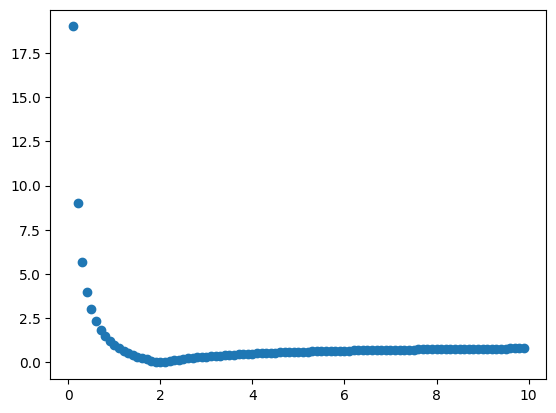

In [ ]:
sample_target = 2
x = np.arange(0, 10, 0.1)
plt.scatter(x, np.abs(x-sample_target)/x)

In [ ]:
def np_metric(y_true, y_pred):
    return np.sum(np.abs(y_true-y_pred))/np.sum(y_pred)

def keras_metric(y_true, y_pred):
    return O.sum(O.absolute(y_true-y_pred))/O.sum(y_pred)

eval_xgb(x_train, x_test, y_train, y_test, np_metric)
eval_nn(x_train, x_test, y_train, y_test, keras.initializers.Constant(mean_target), "mean_squared_error", keras_metric)


XGBoost Train metric: 0.026851306625973945
XGBoost Test metric: 0.043244201584566405


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,961 (660.00 KB)

 Trainable params: 168,961 (660.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - keras_metric: 0.0930 - loss: 12.4865
Epoch 2/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - keras_metric: 0.0775 - loss: 7.9777
Epoch 3/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - keras_metric: 0.0725 - loss: 7.0192
Epoch 4/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - keras_metric: 0.0694 - loss: 6.4848
Epoch 5/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - keras_metric: 0.0675 - loss: 6.1698
Epoch 6/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - keras_metric: 0.0656 - loss: 5.8727
Epoch 7/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - keras_metric: 0.0645 - loss: 5.6918
Epoch 8/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - keras_metric: 0.0628 - loss: 5.4187
Epoch 9/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - keras_metric: 0.0617 - loss: 5.2637
Epoch 10/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - keras_metric: 0.0603 - loss: 5.0498
Epoch 11/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - keras_metric: 0.0595 - 

```That loss function seems a bit suspicious. Let's have a closer look. Implement it (for batches - why can't you properly train a sgd on this loss?), and see if the network exhibits reasonal behavior.
The British people take pride for their meticulous examinations of networks. What happens if the network decides, for some reason, to predict negative values? Try train a network that initializes to predict negative values (maybe change the last bias again). Can you understand the behavior of the loss during training?```

In [ ]:
eval_nn(x_train, x_test, y_train, y_test, bias=keras.initializers.Constant(-50), loss=keras_metric)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,961 (660.00 KB)

 Trainable params: 168,961 (660.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4.6578 - mean_squared_error: 2172.2139
Epoch 2/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.5153 - mean_squared_error: 1574.5211
Epoch 3/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.4161 - mean_squared_error: 595.1453
Epoch 4/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.3781 - mean_squared_error: 347.4364
Epoch 5/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3531 - mean_squared_error: 257.8575
Epoch 6/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.3339 - mean_squared_error: 213.9946
Epoch 7/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3141 - mean_squared_error: 176.9358
Epoch 8/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2917 - mean_squared_error: 144.5401
Epoch 9/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2656 - mean_squared_error: 114.0045
Epoch 10/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2354 - mean_squared_error: 83.8350

```Compare neural networks trained with this special loss, with MSE and with MAE. Which one achieves the best MAE loss? which one achieves the best special loss?```

In [ ]:
eval_nn(x_train, x_test, y_train, y_test, bias=keras.initializers.Constant(mean_target), metric=[keras.losses.MeanAbsoluteError(), keras_metric])
print("^: MSE")
eval_nn(x_train, x_test, y_train, y_test, bias=keras.initializers.Constant(mean_target), loss=keras_metric, metric=[keras.losses.MeanAbsoluteError(), keras_metric])
print("^: special loss")
eval_nn(x_train, x_test, y_train, y_test, bias=keras.initializers.Constant(mean_target), loss=keras.losses.MeanAbsoluteError(), metric=[keras.losses.MeanAbsoluteError(), keras_metric])
print("^: MAE")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,961 (660.00 KB)

 Trainable params: 168,961 (660.00 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,961 (660.00 KB)

 Trainable params: 168,961 (660.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - keras_metric: 0.0924 - loss: 2.5601 - mean_absolute_error: 2.5589
Epoch 2/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - keras_metric: 0.0767 - loss: 2.1210 - mean_absolute_error: 2.1205
Epoch 3/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - keras_metric: 0.0719 - loss: 1.9935 - mean_absolute_error: 1.9931
Epoch 4/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - keras_metric: 0.0693 - loss: 1.9233 - mean_absolute_error: 1.9231
Epoch 5/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - keras_metric: 0.0676 - loss: 1.8747 - mean_absolute_error: 1.8751
Epoch 6/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - keras_metric: 0.0660 - loss: 1.8329 - mean_absolute_error: 1.8327
Epoch 7/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - keras_metric: 0.0645 - loss: 1.7894 - mean_absolute_error: 1.7892
Epoch 8/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - keras_metric: 0.0629 - loss: 1.7472 - mean_absolute_error: 1.7467
Epoch 9/300
160/160 ━━━━━━━━

The special loss minimizes both itself and MAE

```Iv'e just got an urgent message from the field marshal! He told me, "Hoi, gent, my soldiers are cold! I have soldiers all around this damned globe, spread evenly, but you keep my boys worm only in a few damned countries!". Do you think the field marchel is right? Why is that? Can you change the loss function to take this effect into account (bonus points if you can write it in LaTex)? Train a network using this loss.```

Hes right since the density of the inputs (with regards to their physical location) is not uniform. To fix this we can take 
$$\text{Loss} = \sum _{i} \hat{w}(s_i) \cdot (y_{\text{pred}} - y_{\text{true}})^2$$
where $s_i$ is the station of sample $i$ and $w(s) = \frac1{\#(\text{samples with station s})}$ so denser areas get less weight, and $\hat{w}(s) = \frac{w(s)}{\text{mean}(w)}$



In [ ]:
station_weights = np.array(station_weights.to_list())/station_weights.mean()
eval_nn(x_train, x_test, y_train, y_test, bias=keras.initializers.Constant(mean_target), weights=station_weights)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,961 (660.00 KB)

 Trainable params: 168,961 (660.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 15.4071 - mean_squared_error: 13.1890
Epoch 2/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.3873 - mean_squared_error: 8.6291
Epoch 3/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.3837 - mean_squared_error: 7.7546
Epoch 4/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.8134 - mean_squared_error: 7.2710
Epoch 5/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.4138 - mean_squared_error: 6.8923
Epoch 6/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.1450 - mean_squared_error: 6.6429
Epoch 7/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.0464 - mean_squared_error: 6.4751
Epoch 8/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.6530 - mean_squared_error: 6.1441
Epoch 9/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.6317 - mean_squared_error: 6.0618
Epoch 10/300
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.2732 - mean_squared_error: 5.7598
Epoch 11/300
160/160 ━━━━

```Something here smells fhisy as a drunk french on sunday morning. Try comparing the network you trained using the new loss with the other networks you trained so far, using all the metrics we used so far. What results did you get? Can you explain your results?```

In [ ]:
eval_nn(x_train, x_test, y_train, y_test, bias=keras.initializers.Constant(mean_target), weights=station_weights, metric=[keras_metric, "mae", "mse"])

Model: "functional_76"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_82 (InputLayer)     │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_307 (Dense)               │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_308 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_309 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_310 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,521 (170.00 KB)

 Trainable params: 43,521 (170.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - keras_metric: 0.0946 - loss: 15.2809 - mae: 2.6211 - mse: 12.8082
Epoch 2/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - keras_metric: 0.0804 - loss: 9.2788 - mae: 2.2281 - mse: 8.4808
Epoch 3/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - keras_metric: 0.0762 - loss: 8.2644 - mae: 2.1128 - mse: 7.6323
Epoch 4/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - keras_metric: 0.0734 - loss: 7.6916 - mae: 2.0360 - mse: 7.1067
Epoch 5/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - keras_metric: 0.0718 - loss: 7.4081 - mae: 1.9922 - mse: 6.8415
Epoch 6/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - keras_metric: 0.0701 - loss: 7.1370 - mae: 1.9455 - mse: 6.5621
Epoch 7/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - keras_metric: 0.0688 - loss: 6.8898 - mae: 1.9110 - mse: 6.3501
Epoch 8/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - keras_metric: 0.0674 - loss: 6.6567 - mae: 1.8721 - mse: 6.1220
Epoch 9/200
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

Metrics arent the best, perhaps because very sparse areas contribute disproportionately

```Train the best model you can to answer for the field marchel's needs and win the war!```

In [ ]:
mae = lambda y_true, y_predict: np.mean(np.abs(y_true-y_predict))
eval_xgb(x_train, x_test, y_train, y_test, mae)
eval_xgb(x_train, x_test, y_train, y_test, mean_squared_error)

NameError: name 'eval_xgb' is not defined